In [3]:
import wntr
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:

# Create water network model OBJECT
wn = wntr.network.WaterNetworkModel('Net3.inp')

# Calculate population per junction
# This uses water demand at each junction to estimate how many people live in the area served by that junction.
# Example: if a junction uses a lot of water, it probably serves more people.
population = wntr.metrics.population(wn)

In [6]:
# Define simulation parameters 


# 2 hours is when the pipe break starts
start_time = 2*3600 
# 12 hours is how long the pipe is broken
break_duration = 12*3600 


# 2 hours before the break + 12 hours of break 
# = 14 hours of simulation
total_duration = start_time + break_duration 


# PARAMETERS

# If a junction falls below this → no water is delivered.
minimum_pressure = 3.52 # 5 psi
# If the junction’s pressure is below this but above minimum_pressure 
# → partial water delivery.
required_pressure = 14.06 # 20 psi 
# Minimum pipe diameter to include in the analysis.
min_pipe_diam = 0.3048 # 12 inch

In [8]:
# BASELINE SIMULATION

# Calculate the average expected demand (AED) and identify the junctions with non-zero AED
AED = wntr.metrics.average_expected_demand(wn)
nzd_junct = AED[AED > 0].index


# Set hydraulic parameters

# if pressure is low, junctions get less water; vice versa
wn.options.hydraulic.demand_model = 'PDD'
# Sets how long the simulation will run (we defined total_duration in previous cell).
wn.options.time.duration = total_duration
# set thresholds defined in previous celll
wn.options.hydraulic.minimum_pressure = minimum_pressure
wn.options.hydraulic.required_pressure = required_pressure 

# Simulate the hydraulics
sim = wntr.sim.WNTRSimulator(wn)
results = sim.run_sim()

# Save junction pressure results and identify junctions that fall below minimum pressure
    # this is extracted from the simulation results
pressure = results.node['pressure'].loc[start_time::, nzd_junct]  # select pressures from the start_time onwards for non-zero demand junctions.

# Checks which junctions ever drop below the minimum pressure during NORMAL operation.
    # saves these as normal_pressure_below_pmin
normal_pressure_below_pmin = pressure.columns[(pressure < minimum_pressure).any()]

In [10]:
# PIPE BREAK SIMULATIONS

# Create dictionary to save results
analysis_results = {} 

# Query all pipes with diameter greater than threshold set earlier to include in analysis
pipes_of_interest = wn.query_link_attribute('diameter', np.greater_equal, min_pipe_diam)

# Simulate pipe break (simulated as pipe closures) for each pipe
for pipe_name in pipes_of_interest.index: 
    wn = wntr.network.WaterNetworkModel('Net3.inp')
    wn.options.hydraulic.demand_model = 'PDD'    
    wn.options.time.duration = total_duration
    wn.options.hydraulic.minimum_pressure = minimum_pressure
    wn.options.hydraulic.required_pressure = required_pressure
    
    # Create pipe closure control and apply to pipe of interest
    pipe = wn.get_link(pipe_name)
    act = wntr.network.controls.ControlAction(pipe, 'status', 0)
    cond = wntr.network.controls.SimTimeCondition(wn, 'Above', start_time)
    ctrl = wntr.network.controls.Control(cond, act)
    wn.add_control('close pipe ' + pipe_name, ctrl)
    
    try:
        # Simulate hydraulics
        sim = wntr.sim.WNTRSimulator(wn) 
        sim_results = sim.run_sim()
 
        # Identify impacted junctions using pressure results
        sim_pressure = sim_results.node['pressure'].loc[start_time::, nzd_junct]
        sim_pressure_below_pmin = sim_pressure.columns[(sim_pressure < minimum_pressure).any()]
        impacted_junctions = set(sim_pressure_below_pmin) - set(normal_pressure_below_pmin)
        impacted_junctions = list(impacted_junctions)
        
    except Exception as e:
        # Identify failed simulations and the reason
        impacted_junctions = None
        print(pipe_name, ' Failed:', e)

    finally:
        # Save simulation results
        analysis_results[pipe_name] = impacted_junctions

In [11]:
# RESULTS - I
# Calculate and save junction and population impact results to dictionary
num_junctions_impacted = {}
num_people_impacted = {}
for pipe_name, impacted_junctions in analysis_results.items():
    if impacted_junctions is not None:
        num_junctions_impacted[pipe_name] = len(impacted_junctions)
        num_people_impacted[pipe_name] = population[impacted_junctions].sum()

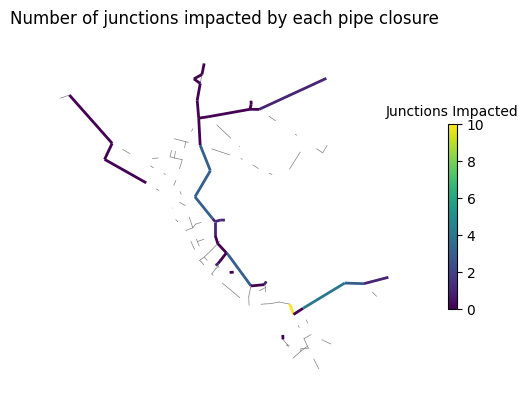

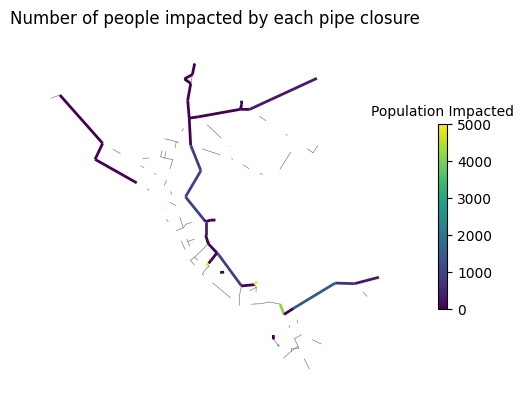

<Axes: title={'center': 'Number of people impacted by each pipe closure'}>

In [12]:
# RESULTS - II
# Set colormap for network maps
cmap=matplotlib.colormaps['viridis']

# Plot junctions impacted due to pipe breaks
# The parameter `link_range` can be adjusted to better suit the simulation results of the network used in the analysis  
wntr.graphics.plot_network(wn, link_attribute=num_junctions_impacted, node_size=0, link_width=2, 
                           link_range=[0,10], link_cmap = cmap, link_colorbar_label='Junctions Impacted', 
                           title='Number of junctions impacted by each pipe closure')

# Plot population impacted due to pipe breaks
wntr.graphics.plot_network(wn, link_attribute=num_people_impacted, node_size=0, link_width=2, 
                           link_range=[0,5000], link_cmap = cmap, link_colorbar_label='Population Impacted',
                           title='Number of people impacted by each pipe closure')

In [13]:
# SAVING RESUTLS TO CSV FILES

# Save the junction impacted results to CSV
# Check to verify the file was created in the directory
num_junctions_impacted = pd.Series(num_junctions_impacted)
num_junctions_impacted.to_csv('pipe_break_junctions_impacted.csv')

# Save the population impacted results to CSV
num_people_impacted = pd.Series(num_people_impacted)
num_people_impacted.to_csv('pipe_break_people_impacted.csv')

In [ ]:
# AFTER READING/UNDERSTANDIGN THE PREVIOUS TWO CELLS,
# SIMULATE PIPE LEAKS NOW, AND MAKE DECISIONS OF HOW BIG OF LEAKS WE WANT TO DETECT AND LATER PREDICT. 